# Cascadia Texture Building

In this notebook we use Python Image Library to build the texture for Cascadia that will be used in Shellpower.

To start, I've hand-drawn an image of a 125x125mm cell and this will be copy-pasted to form panels and then the whole top shell.

## Basic unit: the cell

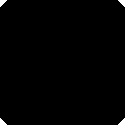

## Panels

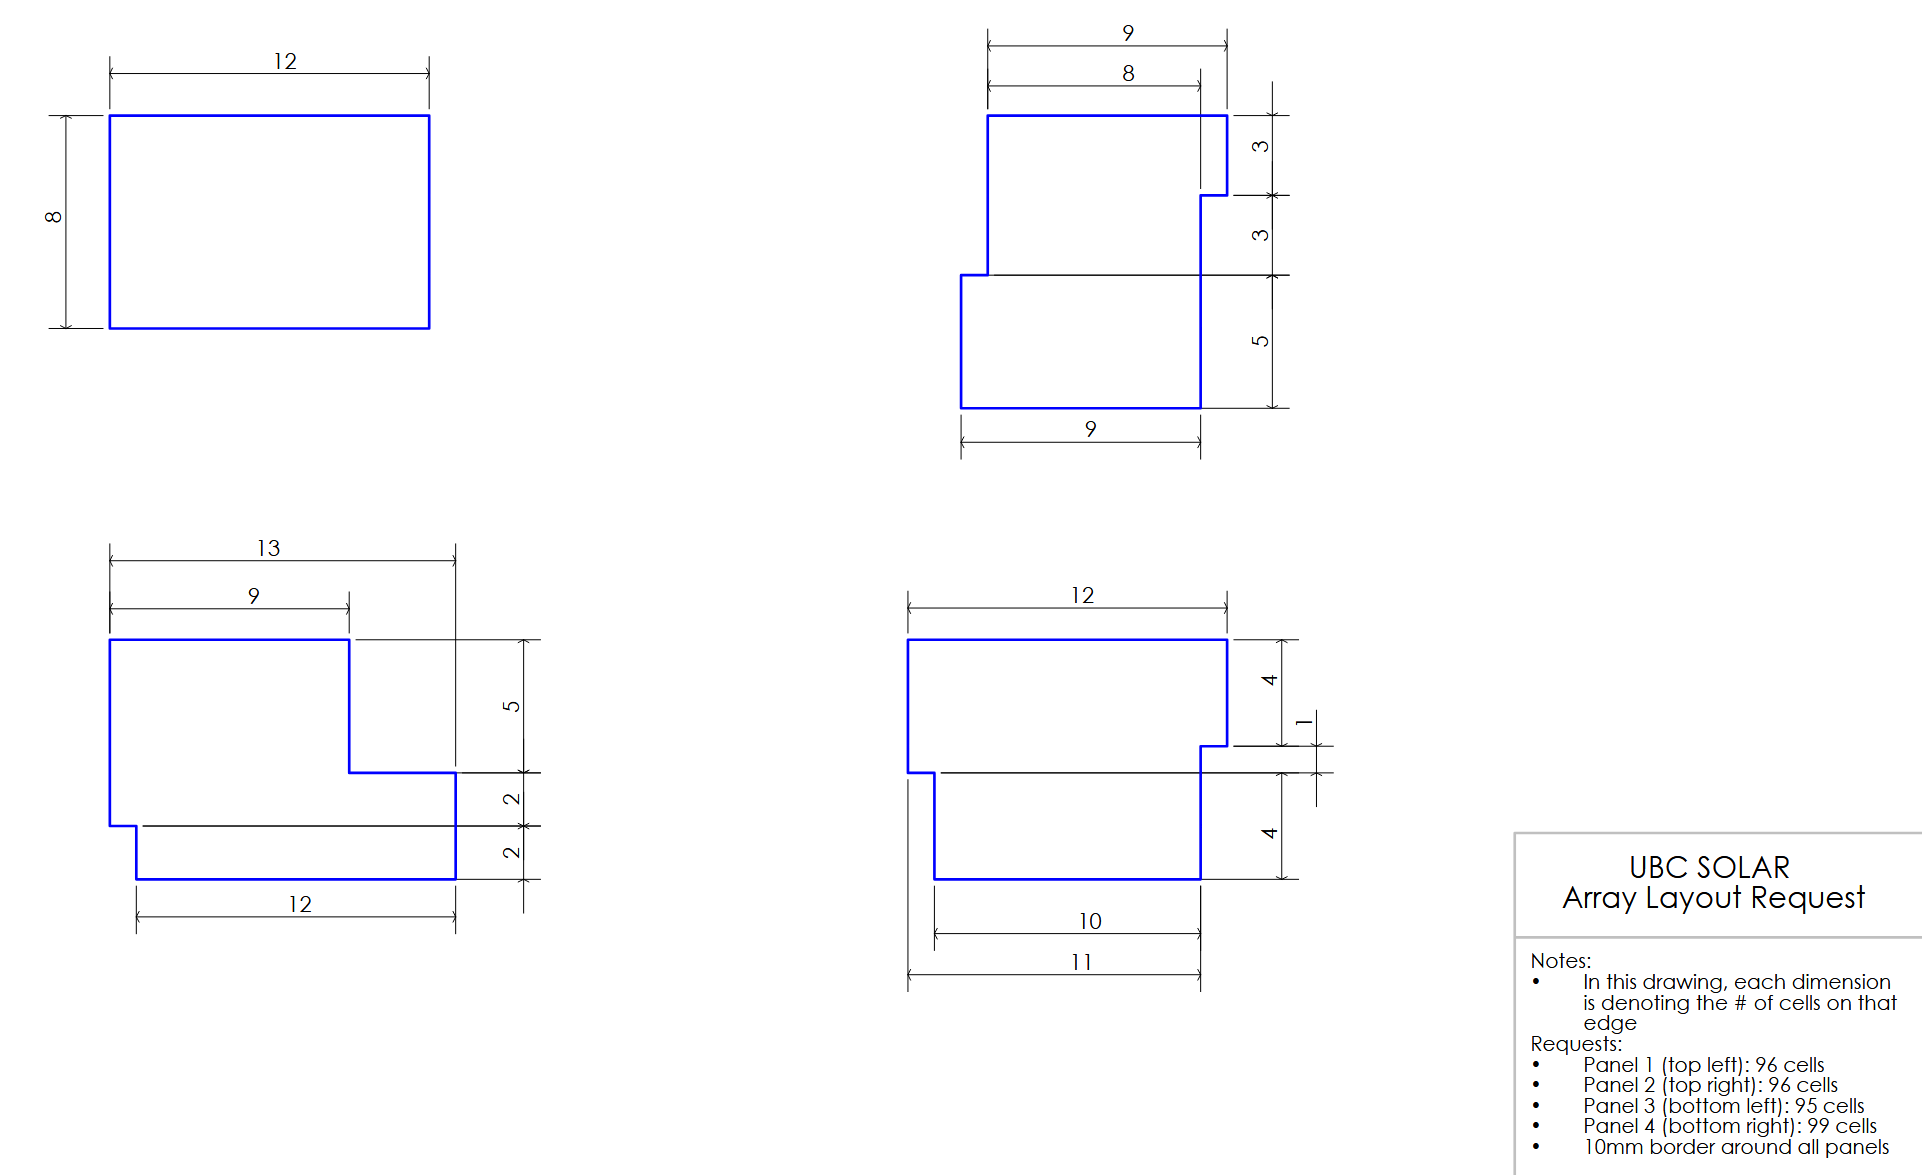

## Entire Array

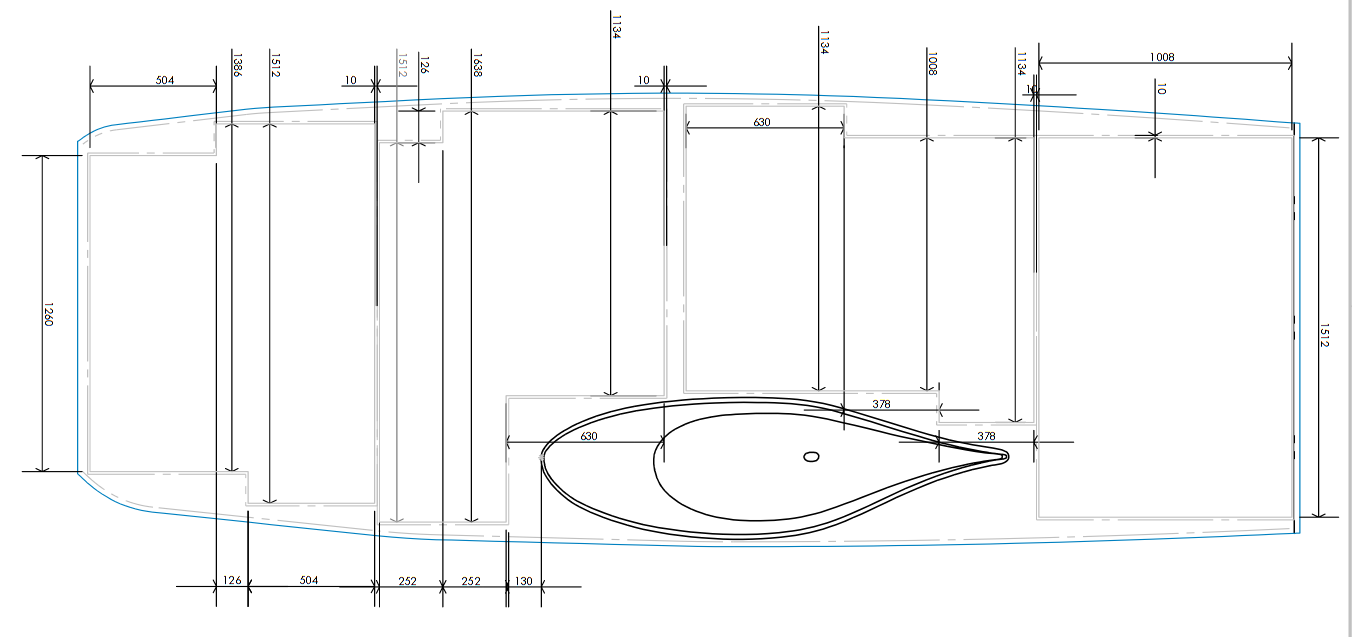

## Imports

In [117]:
from PIL import Image
import os; import sys
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from pathlib import Path

In [118]:
background_color = (255, 255, 255)  # rgb

def set_color(
    cell_img: Image.Image,
    color: tuple[int, int, int],
    replace_color: tuple[int, int, int] | None = None
) -> None:
    """Replaces pixels matching replace_color with color (mutates image in place)."""
    if replace_color is None:
        replace_color = (0, 0, 0, 255)

    # Assumes cell_img is already RGB
    pixels = cell_img.load()
    width, height = cell_img.size

    for x in range(width):
        for y in range(height):
            if pixels[x, y] == replace_color:
                pixels[x, y] = color

def build_panel(geometry: NDArray, cell_img: Image.Image, rg_pair: tuple[int, int]) -> Image.Image:
    """Build a panel image by tiling cells according to a boolean array

    :param geometry: 2d boolean array, indexed by (x, y). 1 if there is a cell at the given coordinate.
    :param cell_img: Cell image to tile over the geometry
    :param rg_pair: Red/green colour channel value pair, used to distinguish cells.
    """
    # Determine shape of output image
    cell_w, cell_h = cell_img.size
    panel_cw, panel_ch = geometry.shape
    panel_w = panel_cw * cell_h
    panel_h = panel_ch * cell_w

    panel_img: Image.Image = Image.new('RGB', (panel_w, panel_h), color=background_color)

    it = np.nditer(geometry, flags=['multi_index'])
    for cell_bool in it:
        if not cell_bool:
            continue
        x, y = it.multi_index
        cell_loc = (x * cell_h, y * cell_w)

        colored_cell = cell_img.copy()

        r = rg_pair[0]
        g = rg_pair[1]
        b = it.iterindex * 2 # since we have <127 cells, we can make them more distinct
        set_color(colored_cell, (r, g, b))

        panel_img.paste(colored_cell, cell_loc)

    # remove extra 1mm spacing on bottom/right edge
    panel_cropped = panel_img.crop((0, 0, panel_w - 1, panel_h - 1))

    return panel_cropped

assets_path: Path = Path(os.getcwd()) / "assets"

cell_img_path: Path = assets_path / "maxeon_126mm_padded_oneside.png"

In [119]:
p1_geom = np.ones((8, 12)).T
p2_geom = np.array([
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
]).T
p3_geom = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]).T
p4_geom = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
]).T

assert np.count_nonzero(p1_geom) == 96
assert np.count_nonzero(p2_geom) == 96
assert np.count_nonzero(p3_geom) == 95
assert np.count_nonzero(p4_geom) == 99

panel_geoms = (p1_geom, p2_geom, p3_geom, p4_geom)

In [120]:
panels: list[Image.Image] = []
rg_pairs = [
    (255, 127),
    (127, 0),
    (127, 127),
    (0, 127),
    (127, 255),
] # Note: use odd numbers, since even numbers could potentially result in rgb being grayscale and interpreted as bg

for i, (panel_geom, rg_pair) in enumerate(zip(panel_geoms, rg_pairs)):
    with Image.open(cell_img_path) as cell_img:
        panel = build_panel(panel_geom, cell_img, rg_pair)
        panels.append(panel)

        panel_img_path: Path = assets_path / f"panel{i+1}.png"

        panel.save(panel_img_path)
        panel.show() # uncomment to show previews

In [121]:
texture_size = (4800, 1700) # TODO: get actual values

panel_layout: list[dict] = [
    {
        'name': 'panel 1',
        'rotation_ccw' : Image.Transpose.ROTATE_90,
        'top_left': (0, 0),
        'image': panels[0],
    },
    {
        'name': 'panel 2',
        'rotation_ccw' : Image.Transpose.ROTATE_90,
        'top_left': (1018, 3*126),
        'image': panels[1],
    },
    {
        'name': 'panel 3',
        'rotation_ccw' : Image.Transpose.ROTATE_90,
        'top_left': (1018+1400, 0),
        'image': panels[2],
    },
    {
        'name': 'panel 4',
        'rotation_ccw' : Image.Transpose.ROTATE_90,
        'top_left': (1018 + 1400 + 9*126 + 10, 1*126),
        'image': panels[3],
    },
]

texture_img: Image.Image = Image.new('RGB', texture_size, color=background_color)

for panel in panel_layout:
    print(f"Placing panel {panel['name']}")

    panel_w, panel_h = panel['image'].size

    rotated_panel = panel['image'].copy().transpose(panel['rotation_ccw'])

    texture_img.paste(rotated_panel, panel['top_left'])

texture_img.show()

Placing panel panel 1
Placing panel panel 2
Placing panel panel 3
Placing panel panel 4


In [122]:
pixels = texture_img.get_flattened_data()

non_white_count = sum(1 for p in pixels if p != (255, 255, 255))

print(f"Total black pixel area: {non_white_count / 1e6} m^2")

Total black pixel area: 5.988018 m^2


In [124]:
texture_img.save(
    assets_path / "cascadia_v1.png",
    format="PNG",
)

In [125]:
texture_img.transpose(Image.Transpose.ROTATE_90)
texture_img.save(
    assets_path / "cascadia_v1_180.png",
    format="PNG",
)